<>:341: SyntaxWarning: "\I" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\I"? A raw string is also an option.
<>:341: SyntaxWarning: "\I" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\I"? A raw string is also an option.
C:\Users\tanay\AppData\Local\Temp\ipykernel_16104\1630229140.py:341: SyntaxWarning: "\I" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\I"? A raw string is also an option.
  print(f"\INTERPRETATION:")


After dropping NaN in required columns: 628 data points

TRIPLE POWER LAW FIT WITH ALL THREE VARIABLES
Using 628 valid data points for fitting
Filtered out 0 points with Mstar <= 0
[[Model]]
    Model(triple_power_law)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 17
    # data points      = 628
    # variables        = 3
    chi-square         = 219.277129
    reduced chi-square = 0.35084341
    Akaike info crit   = -654.783992
    Bayesian info crit = -641.456371
    R-squared          = 0.43507516
[[Variables]]
    log_amplitude: -4.35928348 +/- 0.29513495 (6.77%) (init = -7)
    age_exponent:  -0.58533023 +/- 0.04588644 (7.84%) (init = -1)
    mass_exponent:  1.87515336 +/- 0.08777894 (4.68%) (init = 1)
[[Correlations]] (unreported correlations are < 0.100)
    C(log_amplitude, age_exponent)  = -0.9964
    C(log_amplitude, mass_exponent) = +0.4057
    C(age_exponent, mass_exponent)  = -0.3807

BEST-FIT TRIPLE POWER LAW IN LOG SPACE:
logMacc = -4.359 +

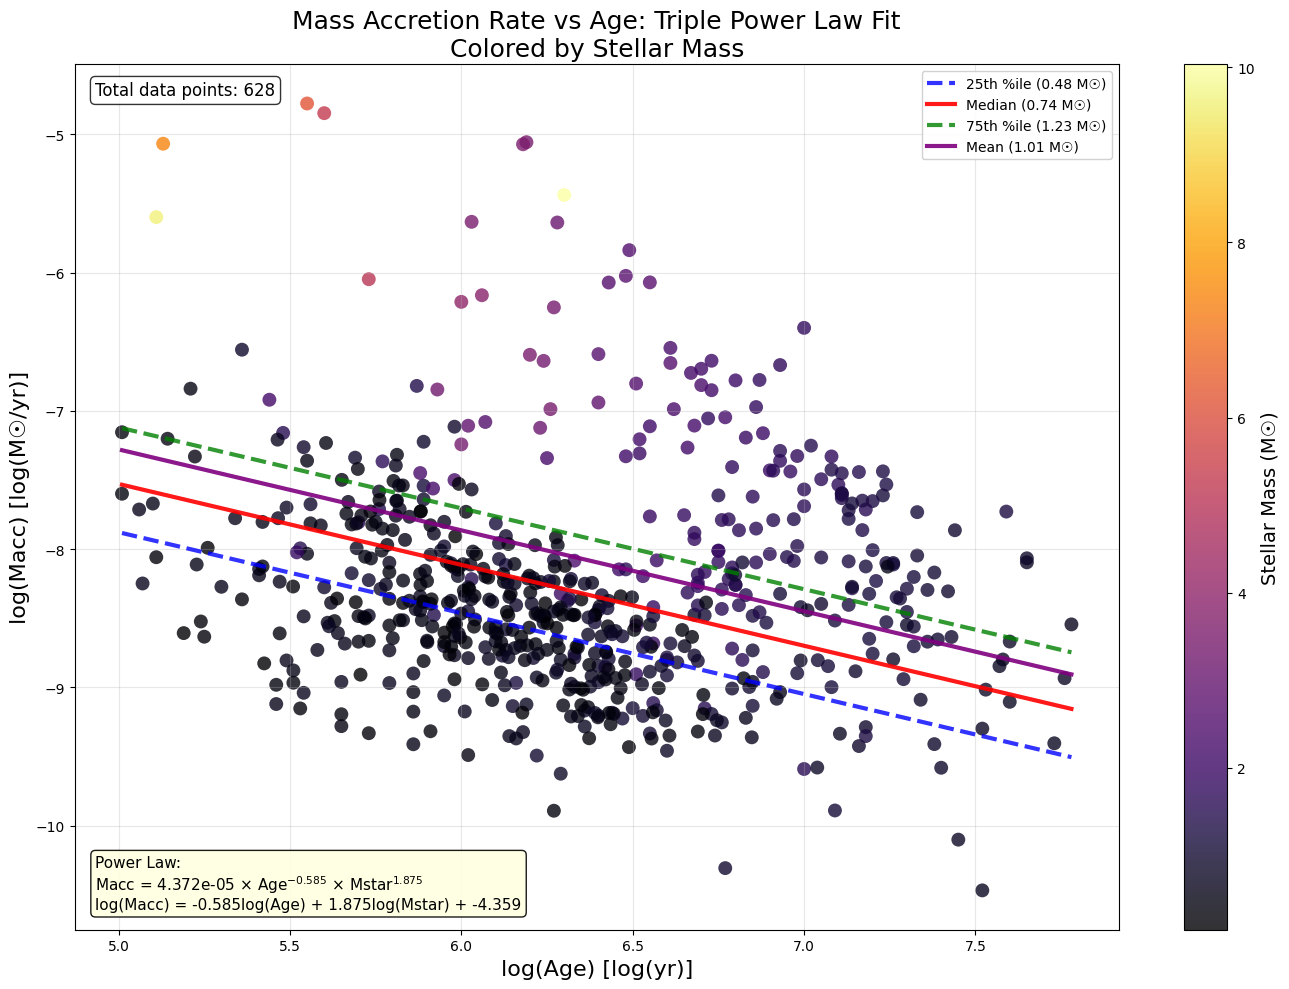


COMPREHENSIVE ANALYSIS SUMMARY

DATA STATISTICS:
Total data points: 628
logMacc range: -10.469 to -4.777
logAge range: 5.010 to 7.780
Mstar range: 0.149 to 10.037 Solar Masses
logMstar range: -0.827 to 1.002 Solar Masses

CORRELATIONS:
logAge vs logMacc: -0.150
logMstar vs logMacc: 0.537
logAge vs logMstar: 0.381
\INTERPRETATION:
TRIPLE POWER LAW: log(Macc) = -0.585log(Age) + 1.875log(Mstar) + -4.359
  → Mass accretion decreases with age (expected)
  → More massive stars have higher accretion rates (expected)


In [1]:
from astropy.io import ascii
import matplotlib.pyplot as plt
import numpy as np
import lmfit
import pandas as pd
from sklearn.linear_model import LinearRegression
from matplotlib.backends.backend_pdf import PdfPages
import datetime

# Load data
file_path = 'compilation_Venuti_2024_Serna_2021.csv'
df = pd.read_csv(file_path)

# dropna to drop rows with missing data
df = df.dropna(subset=['logAge', 'Mstar', 'logMacc'])
print(f"After dropping NaN in required columns: {len(df)} data points")

# Convert to linear space for power law fitting
df['Age_linear'] = 10**df['logAge']  # Age in years
df['Macc_linear'] = 10**df['logMacc']  # Macc in Solar Masses/yr

#Convert to log space for power law fitting
df['logMstar'] = np.log10(df['Mstar']) #Mstar in Solar Masses

# Create single figure
fig, ax = plt.subplots(1, 1, figsize=(14, 10))

# ============================================================================
# TRIPLE POWER LAW FIT (using all three variables: Age, Mstar, Macc)
# ============================================================================
print("\n" + "="*60)
print("TRIPLE POWER LAW FIT WITH ALL THREE VARIABLES")
print("="*60)

def triple_power_law(log_age, log_mstar, log_amplitude, age_exponent, mass_exponent):
    """
    Power law model incorporating all three variables:
    log(Macc) = log_amplitude + age_exponent*log(Age) + mass_exponent*log(Mstar)
    Corresponding equation: Macc = 10^(log_amplitude) * Age^(age_exponent) * Mstar^(mass_exponent)
    """
    return log_amplitude + age_exponent * log_age + mass_exponent * log_mstar

# Create the model and specify independent variables
model_triple = lmfit.Model(triple_power_law, independent_vars=['log_age', 'log_mstar'])

# Set initial parameters with reasonable bounds
params = model_triple.make_params()
params.add('log_amplitude', value=-7, min=-12, max=5)
params.add('age_exponent', value=-1.0, min=-30.0, max=30.0)
params.add('mass_exponent', value=1.0, min=-30.0, max=30.0)

# Initialize variables
amp_linear = log_amp = age_exp = mass_exp = None
result_triple = None

try:
    # Ensure we're using numpy arrays for fitting
    log_age_data = np.array(df['logAge'].values, dtype=float)
    log_mstar_data = np.array(df['logMstar'].values, dtype=float)
    log_macc_data = np.array(df['logMacc'].values, dtype=float)
    
    # FIX: Remove any zeros or negative values from ORIGINAL Mstar, not logMstar
    valid_mask = (df['Mstar'].values > 0)  # Filter on original linear values
    
    log_age_data = log_age_data[valid_mask]
    log_mstar_data = log_mstar_data[valid_mask]
    log_macc_data = log_macc_data[valid_mask]
    
    print(f"Using {len(log_age_data)} valid data points for fitting")
    print(f"Filtered out {len(df) - len(log_age_data)} points with Mstar <= 0")
    
    # Fit the triple power law model
    result_triple = model_triple.fit(log_macc_data, params, log_age=log_age_data, log_mstar=log_mstar_data)
    
    print(result_triple.fit_report())
    
    # Extract best-fit parameters
    log_amp = result_triple.params['log_amplitude'].value
    age_exp = result_triple.params['age_exponent'].value
    mass_exp = result_triple.params['mass_exponent'].value
    
    # Convert back to linear amplitude for interpretation
    amp_linear = 10**log_amp
    
    print(f"\nBEST-FIT TRIPLE POWER LAW IN LOG SPACE:")
    print(f"logMacc = {log_amp:.3f} + {age_exp:.3f}×logAge + {mass_exp:.3f}×log(Mstar)")
    print(f"Which corresponds to:")
    print(f"Macc = {amp_linear:.3e} × Age^{age_exp:.3f} × Mstar^{mass_exp:.3f}")
    
except Exception as e:
    print(f"Triple power law analysis failed: {e}")
    import traceback
    traceback.print_exc()

if result_triple is not None:
    print(f"amp_linear: {amp_linear}")
    print(f"age_exp: {age_exp}") 
    print(f"mass_exp: {mass_exp}")
    print(f"log_amp: {log_amp}")
else:
    print("Triple power law fit failed - skipping debug prints")

"""
# ============================================================================
# SIMPLE POWER LAW FIT (only Age and Macc)
# ============================================================================
print("\n" + "="*60)
print("SIMPLE POWER LAW FIT (Age and Macc only)")
print("="*60)

def simple_power_law(x, amplitude, exponent):
      Power law model: y = amplitude * x^exponent
    return amplitude * (10**x)**exponent  # Convert logAge back to linear scale for power law

# Prepare data for simple power law fitting
x_data = df['logAge'].values
y_data = 10**df['logMacc'].values  # Convert logMacc back to linear scale for fitting

# Create and fit the simple power law model
model_simple = lmfit.Model(simple_power_law)
params_simple = model_simple.make_params(amplitude=1e-7, exponent=-1)

# Set parameter bounds
params_simple['amplitude'].min = 1e-10
params_simple['amplitude'].max = 1e-5
params_simple['exponent'].min = -3
params_simple['exponent'].max = 0

result_simple = None
try:
    result_simple = model_simple.fit(y_data, params_simple, x=x_data)
    print(result_simple.fit_report())
    
    print(f"\nBEST-FIT SIMPLE POWER LAW:")
    print(f"Macc = {result_simple.params['amplitude'].value:.3e} × Age^{result_simple.params['exponent'].value:.3f}")
    
except Exception as e:
    print(f"Simple power law fitting failed: {e}")

# ============================================================================
# LINEAR REGRESSION FIT
# ============================================================================
print("\n" + "="*60)
print("LINEAR REGRESSION FIT")
print("="*60)

result_linear = None
try:
    # Fit a linear regression: logMacc = a*logAge + b
    x_fit_lin = df['logAge'].values.reshape(-1, 1)
    y_fit_lin = df['logMacc'].values
    
    model_lin = LinearRegression()
    model_lin.fit(x_fit_lin, y_fit_lin)
    
    print(f"Linear regression: logMacc = {model_lin.coef_[0]:.3f}*logAge + {model_lin.intercept_:.3f}")
    result_linear = model_lin
    
except Exception as e:
    print(f"Linear regression failed: {e}")
"""
# ============================================================================
# PLOTTING ALL RESULTS ON SINGLE GRAPH
# ============================================================================

# Plot all data points colored by stellar mass
scatter = ax.scatter(df['logAge'], df['logMacc'], 
                    c=df['Mstar'],
                    cmap='inferno',
                    marker='o', 
                    edgecolors='none',
                    alpha=0.8, 
                    s=100)

# Add colorbar to show the Mstar scale
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Stellar Mass (M☉)', fontsize=14)

# Calculate percentile masses for additional fit lines
if result_triple is not None:
    mstar_25 = df['Mstar'].quantile(0.25)
    mstar_50 = df['Mstar'].median()  # Using median instead of mean for better representation
    mstar_75 = df['Mstar'].quantile(0.75)
    mstar_mean = df['Mstar'].mean()
    # mstar_custom = 3.5  # Example custom mass value for additional fit line
    
    print(f"\nStellar mass percentiles for visualization:")
    print(f"25th percentile: {mstar_25:.3f} M☉")
    print(f"50th percentile (median): {mstar_50:.3f} M☉") 
    print(f"75th percentile: {mstar_75:.3f} M☉")
    print(f"Mean stellar mass: {mstar_mean:.3f} M☉")
    # print(f"Custom stellar mass for fit line: {mstar_custom:.3f} M☉")
    
    # Generate fit line for all mass percentiles
    x_fit_log = np.linspace(df['logAge'].min(), df['logAge'].max(), 100)
    age_fit_linear = 10**x_fit_log
    
    # Calculate triple power law predictions for each mass percentile
    macc_fit_25 = amp_linear * np.power(age_fit_linear, age_exp) * np.power(mstar_25, mass_exp)
    macc_fit_50 = amp_linear * np.power(age_fit_linear, age_exp) * np.power(mstar_50, mass_exp)
    macc_fit_75 = amp_linear * np.power(age_fit_linear, age_exp) * np.power(mstar_75, mass_exp)
    macc_fit_mean = amp_linear * np.power(age_fit_linear, age_exp) * np.power(mstar_mean, mass_exp)
    # macc_fit_custom = amp_linear * np.power(age_fit_linear, age_exp) * np.power(mstar_custom, mass_exp)
    
    print(f"macc_fit range - 25th: {macc_fit_25.min():.3e} to {macc_fit_25.max():.3e}")
    print(f"macc_fit range - 50th: {macc_fit_50.min():.3e} to {macc_fit_50.max():.3e}")
    print(f"macc_fit range - 75th: {macc_fit_75.min():.3e} to {macc_fit_75.max():.3e}")
    print(f"macc_fit range - Mean: {macc_fit_mean.min():.3e} to {macc_fit_mean.max():.3e}")
    # print(f"macc_fit range - Custom: {macc_fit_custom.min():.3e} to {macc_fit_custom.max():.3e}")
    
    # Plot all four fit lines with different colors and labels
    ax.plot(x_fit_log, np.log10(macc_fit_25), 'blue', linewidth=3, alpha=0.8, linestyle='--',
            label=f'25th %ile ({mstar_25:.2f} M☉)')
    
    ax.plot(x_fit_log, np.log10(macc_fit_50), 'red', linewidth=3, alpha=0.9,
            label=f'Median ({mstar_50:.2f} M☉)')
    
    ax.plot(x_fit_log, np.log10(macc_fit_75), 'green', linewidth=3, alpha=0.8, linestyle='--',
            label=f'75th %ile ({mstar_75:.2f} M☉)')
    
    ax.plot(x_fit_log, np.log10(macc_fit_mean), 'purple', linewidth=3, alpha=0.9,
            label=f'Mean ({mstar_mean:.2f} M☉)')
    
    # ax.plot(x_fit_log, np.log10(macc_fit_custom), 'orange', linewidth=3, alpha=0.9, linestyle=':',
            # label=f'Custom ({mstar_custom:.2f} M☉)')
    
    # LEGEND FOR FIT LINES - TOP RIGHT
    if result_triple is not None:
        ax.legend(fontsize=10, loc='upper right', framealpha=0.9)

# Configure plot appearance
ax.set_xlabel('log(Age) [log(yr)]', fontsize=16)
ax.set_ylabel('log(Macc) [log(M☉/yr)]', fontsize=16)
ax.set_title('Mass Accretion Rate vs Age: Triple Power Law Fit\nColored by Stellar Mass', fontsize=18)
ax.grid(True, alpha=0.3)

# Add statistics to plot - TOP LEFT
stats_text = f'Total data points: {len(df)}'
ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, 
        verticalalignment='top', fontsize=12,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# ADD EQUATIONS - BOTTOM LEFT
if result_triple is not None:
    # Main power law equation
    eq_text_main = (f'Power Law:\nMacc = {amp_linear:.3e} × Age$^{{{age_exp:.3f}}}$ × Mstar$^{{{mass_exp:.3f}}}$\n'
                   f'log(Macc) = {age_exp:.3f}log(Age) + {mass_exp:.3f}log(Mstar) + {log_amp:.3f}')
    
    ax.text(0.02, 0.02, eq_text_main, transform=ax.transAxes,
            verticalalignment='bottom', fontsize=11,
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9))

plt.tight_layout()

# ============================================================================
# CREATE COMBINED PDF WITH TEXT AND IMAGE
# ============================================================================
def create_combined_pdf():
    with PdfPages('CapstoneReport_Oct10_Tanay.pdf') as pdf:
        # First page: Text results
        fig_text, ax_text = plt.subplots(figsize=(8.5, 11))  # Letter size
        ax_text.axis('off')  # Hide axes
        
        # Prepare text content
        text_content = []
        text_content.append("Capstone Project Report")
        text_content.append(f"By: Tanay Ayiliath")
        text_content.append("TRIPLE POWER LAW FIT ANALYSIS RESULTS")
        text_content.append("=" * 50)
        text_content.append("")
        text_content.append("DATA STATISTICS:")
        text_content.append(f"Total data points: {len(df)}")
        text_content.append(f"logMacc range: {df['logMacc'].min():.3f} to {df['logMacc'].max():.3f}")
        text_content.append(f"logAge range: {df['logAge'].min():.3f} to {df['logAge'].max():.3f}")
        text_content.append(f"Mstar range: {df['Mstar'].min():.3f} to {df['Mstar'].max():.3f} Solar Masses")
        text_content.append("")
        text_content.append("CORRELATIONS:")
        text_content.append(f"logAge vs logMacc: {df['logAge'].corr(df['logMacc']):.3f}")
        text_content.append(f"logMstar vs logMacc: {df['logMstar'].corr(df['logMacc']):.3f}")
        text_content.append(f"logAge vs logMstar: {df['logAge'].corr(df['logMstar']):.3f}")
        text_content.append("")
        
        if result_triple is not None:
            text_content.append("TRIPLE POWER LAW FIT RESULTS:")
            text_content.append(f"log(Macc) = {log_amp:.3f} + {age_exp:.3f}×logAge + {mass_exp:.3f}×log(Mstar)")
            text_content.append(f"Macc = {amp_linear:.3e} × Age^{age_exp:.3f} × Mstar^{mass_exp:.3f}")
            text_content.append("")
            text_content.append("INTERPRETATION:")
            if age_exp < 0:
                text_content.append("→ Mass accretion decreases with age (expected)")
            else:
                text_content.append("→ UNEXPECTED: mass accretion increases with age")
            if mass_exp > 0:
                text_content.append("→ More massive stars have higher accretion rates (expected)")
            else:
                text_content.append("→ UNEXPECTED: less massive stars have higher accretion rates")
        
        # Add text to page
        ax_text.text(0.05, 0.95, '\n'.join(text_content), 
                    transform=ax_text.transAxes, fontsize=10, 
                    verticalalignment='top', fontfamily='monospace')
        
        pdf.savefig(fig_text, bbox_inches='tight')
        plt.close(fig_text)
        
        # Second page: The main plot
        pdf.savefig(fig, bbox_inches='tight')
        
        # Add metadata
        d = pdf.infodict()
        d['Title'] = 'Triple Power Law Fit Analysis'
        d['Author'] = 'Tanay Ayiliath'
        
    print("Combined PDF report saved as: CapstoneReport_Oct10_Tanay.pdf")

# Create the combined PDF
create_combined_pdf()

# Also show the plot
plt.show()

# ============================================================================
# COMPREHENSIVE SUMMARY
# ============================================================================
print("\n" + "="*80)
print("COMPREHENSIVE ANALYSIS SUMMARY")
print("="*80)

print(f"\nDATA STATISTICS:")
print(f"Total data points: {len(df)}")
print(f"logMacc range: {df['logMacc'].min():.3f} to {df['logMacc'].max():.3f}")
print(f"logAge range: {df['logAge'].min():.3f} to {df['logAge'].max():.3f}")
print(f"Mstar range: {df['Mstar'].min():.3f} to {df['Mstar'].max():.3f} Solar Masses")
print(f"logMstar range: {df['logMstar'].min():.3f} to {df['logMstar'].max():.3f} Solar Masses")

print(f"\nCORRELATIONS:")
print(f"logAge vs logMacc: {df['logAge'].corr(df['logMacc']):.3f}")
print(f"logMstar vs logMacc: {df['logMstar'].corr(df['logMacc']):.3f}")
print(f"logAge vs logMstar: {df['logAge'].corr(df['logMstar']):.3f}")

print(f"\INTERPRETATION:")
if result_triple is not None:
    print(f"TRIPLE POWER LAW: log(Macc) = {age_exp:.3f}log(Age) + {mass_exp:.3f}log(Mstar) + {log_amp:.3f}")
    if age_exp < 0:
        print(f"  → Mass accretion decreases with age (expected)")
    else:
        print(f"  → UNEXPECTED: mass accretion increases with age")
        
    if mass_exp > 0:
        print(f"  → More massive stars have higher accretion rates (expected)")
    else:
        print(f"  → UNEXPECTED: less massive stars have higher accretion rates")

# if result_simple is not None:
#     print(f"SIMPLE POWER LAW: Macc ∝ Age^{result_simple.params['exponent'].value:.3f}")
# 
# if result_linear is not None:
#     print(f"LINEAR: logMacc = {result_linear.coef_[0]:.3f}×logAge + {result_linear.intercept_:.3f}")
#     if result_linear.coef_[0] < 0:
#         print(f"  → Negative slope: accretion decreases with age (expected)")
#     else:
#         print(f"  → UNEXPECTED: positive slope suggests accretion increases with age")

# ============================================================================